## Predicting U.S. CPI Inflation Using Machine Learning: ARIMAX, XGBoost, and LSTM

### Data Input

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from fredapi import Fred

import os
FRED_API_KEY = os.environ.get('FRED_API_KEY')
fred = Fred(api_key=FRED_API_KEY)

start = "1983-01-01"
end   = "2024-12-31"

series = {
    "CPI":          "CPIAUCSL",  # Target: Consumer Price Index
    "unemployment": "UNRATE",    # Unemployment rate
    "fed_funds":    "FEDFUNDS",  # Federal funds rate
    "m2":           "M2SL",      # M2 money supply
    "pce":          "PCEPI",     # Personal consumption expenditures
    "sentiment":    "UMCSENT",   # University of Michigan consumer sentiment
    "industrial":   "INDPRO",    # Industrial production index
}

df = pd.DataFrame()
for col, code in series.items():
    df[col] = fred.get_series(code, start, end)

# Use FRED WTI crude oil price (available from 1986)
df["oil_price"] = fred.get_series("MCOILWTICO", start, end)

df.index = pd.to_datetime(df.index)
df = df.resample("MS").first()
df = df.dropna()

print("Shape:", df.shape)
print("Date range:", df.index[0], "to", df.index[-1])
print(df.isnull().sum())

Shape: (468, 8)
Date range: 1986-01-01 00:00:00 to 2024-12-01 00:00:00
CPI             0
unemployment    0
fed_funds       0
m2              0
pce             0
sentiment       0
industrial      0
oil_price       0
dtype: int64


### Feature Engineering 

In [56]:
# 1. Target variable: year-over-year CPI inflation rate (%)
df["inflation"] = df["CPI"].pct_change(12) * 100

# 2. Monthly growth rates to capture momentum
df["oil_change"]    = df["oil_price"].pct_change(1) * 100
df["m2_change"]     = df["m2"].pct_change(1) * 100
df["indpro_change"] = df["industrial"].pct_change(1) * 100

# 3. Lagged inflation features (1, 3, and 6 months)
df["inflation_lag1"] = df["inflation"].shift(1)
df["inflation_lag3"] = df["inflation"].shift(3)
df["inflation_lag6"] = df["inflation"].shift(6)

# 4. Drop rows with missing values
df = df.dropna()

print("Final shape:", df.shape)
print("Date range:", df.index[0], "to", df.index[-1])
print(df[["inflation", "oil_change", "inflation_lag1"]].tail(5))

Final shape: (450, 15)
Date range: 1987-07-01 00:00:00 to 2024-12-01 00:00:00
            inflation  oil_change  inflation_lag1
2024-08-01   2.607144   -6.259169        2.941476
2024-09-01   2.426483   -8.398539        2.607144
2024-10-01   2.578844    2.491458        2.426483
2024-11-01   2.719472   -2.833727        2.578844
2024-12-01   2.870691    0.243031        2.719472


### Exploratory Data Analysis

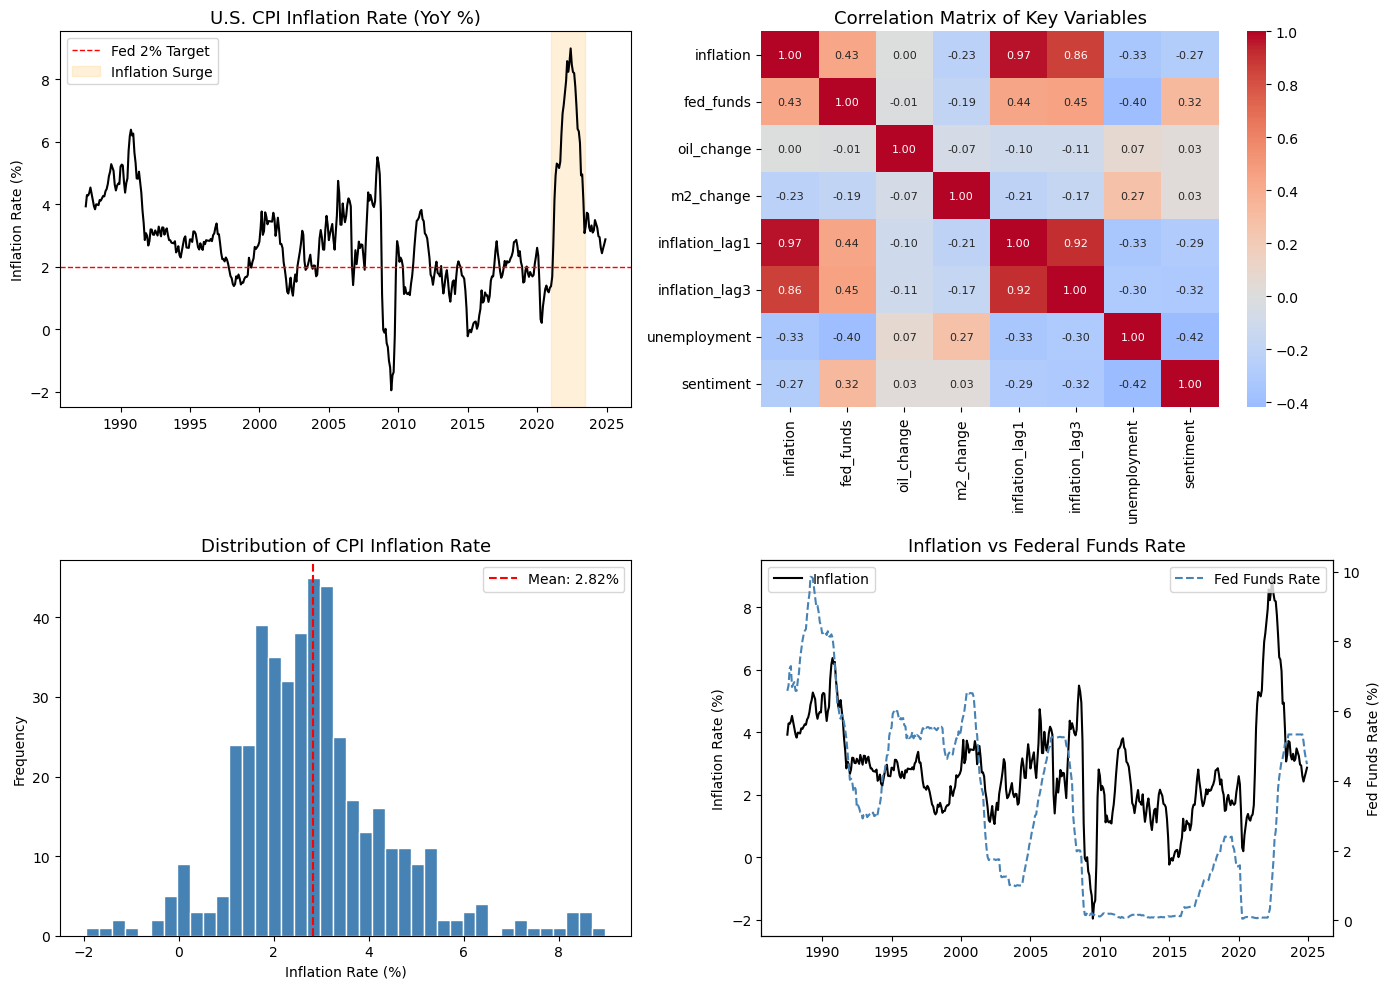

In [57]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. CPI Inflation over time
axes[0,0].plot(df.index, df["inflation"], color="black", linewidth=1.5)
axes[0,0].axhline(2, color="red", linestyle="--", linewidth=1, label="Fed 2% Target")
axes[0,0].axvspan(pd.Timestamp("2021-01-01"), pd.Timestamp("2023-06-01"),
                   alpha=0.15, color="orange", label="Inflation Surge")
axes[0,0].set_title("U.S. CPI Inflation Rate (YoY %)", fontsize=13)
axes[0,0].set_ylabel("Inflation Rate (%)")
axes[0,0].legend()

# 2. Correlation heatmap
corr_cols = ["inflation", "fed_funds", "oil_change", "m2_change",
             "inflation_lag1", "inflation_lag3", "unemployment", "sentiment"]
corr = df[corr_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, ax=axes[0,1], annot_kws={"size": 8})
axes[0,1].set_title("Correlation Matrix of Key Variables", fontsize=13)

# 3. Distribution of inflation rate
axes[1,0].hist(df["inflation"], bins=40, color="steelblue", edgecolor="white")
axes[1,0].axvline(df["inflation"].mean(), color="red", linestyle="--",
                   label=f"Mean: {df['inflation'].mean():.2f}%")
axes[1,0].set_title("Distribution of CPI Inflation Rate", fontsize=13)
axes[1,0].set_xlabel("Inflation Rate (%)")
axes[1,0].set_ylabel("Frequency")
axes[1,0].legend()

# 4. Fed Funds Rate vs Inflation over time
ax2 = axes[1,1].twinx()
axes[1,1].plot(df.index, df["inflation"], color="black",
               linewidth=1.5, label="Inflation")
ax2.plot(df.index, df["fed_funds"], color="steelblue",
         linewidth=1.5, linestyle="--", label="Fed Funds Rate")
axes[1,1].set_title("Inflation vs Federal Funds Rate", fontsize=13)
axes[1,1].set_ylabel("Inflation Rate (%)")
ax2.set_ylabel("Fed Funds Rate (%)")
axes[1,1].legend(loc="upper left")
ax2.legend(loc="upper right")

plt.tight_layout()
plt.savefig("eda.png", dpi=150, bbox_inches="tight")
plt.show()

### LASSO Feature Selection 

Train: 1987-07-01 to 2017-06-01
Test:  2017-07-01 to 2024-12-01

LASSO Coefficients:
          feature  coefficient
7  inflation_lag1     1.410802
8  inflation_lag3    -0.167945
6      oil_change     0.131798
1       fed_funds     0.114561
4       sentiment    -0.071514
9  inflation_lag6    -0.045918
0    unemployment    -0.023672
3             pce    -0.015955
5   indpro_change     0.005012
2       m2_change     0.000000


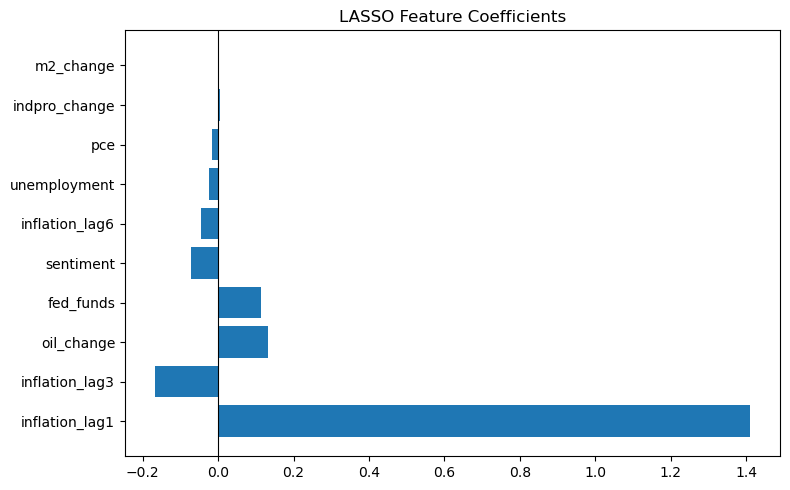

In [58]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler

feature_cols = [
    "unemployment", "fed_funds", "m2_change", "pce",
    "sentiment", "indpro_change", "oil_change",
    "inflation_lag1", "inflation_lag3", "inflation_lag6"
]

X = df[feature_cols]
y = df["inflation"]

# Chronological train/test split (80% / 20%)
split = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

print(f"Train: {X_train.index[0].date()} to {X_train.index[-1].date()}")
print(f"Test:  {X_test.index[0].date()} to {X_test.index[-1].date()}")

# Standardize features
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# LASSO with 5-fold cross-validation
lasso = LassoCV(cv=5, random_state=42, max_iter=10000)
lasso.fit(X_train_sc, y_train)

coef_df = pd.DataFrame({
    "feature": feature_cols,
    "coefficient": lasso.coef_
}).sort_values("coefficient", key=abs, ascending=False)

print("\nLASSO Coefficients:")
print(coef_df)

# Visualize
plt.figure(figsize=(8, 5))
plt.barh(coef_df["feature"], coef_df["coefficient"])
plt.axvline(0, color="black", linewidth=0.8)
plt.title("LASSO Feature Coefficients")
plt.tight_layout()
plt.savefig("lasso_coefficients.png", dpi=150, bbox_inches="tight")
plt.show()

### ARIMAX Model

In [59]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

exog_cols = ["fed_funds", "oil_change", "m2_change"]

exog_train_sc = pd.DataFrame(
    scaler.fit_transform(X_train[exog_cols]),
    columns=exog_cols, index=X_train.index
)
exog_test_sc = pd.DataFrame(
    scaler.transform(X_test[exog_cols]),
    columns=exog_cols, index=X_test.index
)

arimax = SARIMAX(
    y_train, exog=exog_train_sc,
    order=(3, 1, 0), trend="c"
).fit(disp=False)

print(arimax.summary())

arimax_pred = arimax.forecast(steps=len(y_test), exog=exog_test_sc)

mae_arimax  = mean_absolute_error(y_test, arimax_pred)
rmse_arimax = mean_squared_error(y_test, arimax_pred) ** 0.5
print(f"\nARIMAX — MAE: {mae_arimax:.4f}, RMSE: {rmse_arimax:.4f}")

                               SARIMAX Results                                
Dep. Variable:              inflation   No. Observations:                  360
Model:               SARIMAX(3, 1, 0)   Log Likelihood                -131.888
Date:                Wed, 18 Mar 2026   AIC                            279.777
Time:                        18:56:57   BIC                            310.843
Sample:                    07-01-1987   HQIC                           292.131
                         - 06-01-2017                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     -0.0014      0.020     -0.074      0.941      -0.040       0.037
fed_funds      0.7186      0.317      2.267      0.023       0.097       1.340
oil_change     0.0098      0.013      0.772      0.4

### XGBoost Baseline

In [60]:
from xgboost import XGBRegressor

xgb_cols = ["fed_funds", "oil_change", "m2_change",
            "inflation_lag1", "inflation_lag3"]

X_train_xgb = X_train[xgb_cols]
X_test_xgb  = X_test[xgb_cols]

xgb_model = XGBRegressor(
    n_estimators=200, learning_rate=0.05,
    max_depth=3, random_state=42
)
xgb_model.fit(X_train_xgb, y_train)
xgb_pred = xgb_model.predict(X_test_xgb)

mae_xgb  = mean_absolute_error(y_test, xgb_pred)
rmse_xgb = mean_squared_error(y_test, xgb_pred) ** 0.5
print(f"XGBoost (Baseline) — MAE: {mae_xgb:.4f}, RMSE: {rmse_xgb:.4f}")

XGBoost (Baseline) — MAE: 0.6410, RMSE: 1.1465


### XGBoost Hyperparameter Tuning

In [61]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators":  [100, 200, 300],
    "max_depth":     [3, 4, 5],
    "learning_rate": [0.01, 0.05, 0.1],
}

grid_search = GridSearchCV(
    XGBRegressor(random_state=42),
    param_grid, cv=5,
    scoring="neg_mean_absolute_error",
    n_jobs=-1, verbose=1
)
grid_search.fit(X_train_xgb, y_train)

print("Best parameters:", grid_search.best_params_)
print(f"Best CV MAE: {-grid_search.best_score_:.4f}")

best_xgb  = grid_search.best_estimator_
best_pred = best_xgb.predict(X_test_xgb)

mae_best  = mean_absolute_error(y_test, best_pred)
rmse_best = mean_squared_error(y_test, best_pred) ** 0.5
print(f"\nXGBoost (Baseline) — MAE: {mae_xgb:.4f}, RMSE: {rmse_xgb:.4f}")
print(f"XGBoost (Tuned)    — MAE: {mae_best:.4f}, RMSE: {rmse_best:.4f}")

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best parameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200}
Best CV MAE: 0.3816

XGBoost (Baseline) — MAE: 0.6410, RMSE: 1.1465
XGBoost (Tuned)    — MAE: 0.6410, RMSE: 1.1465


### LSTM Model (PyTorch)

In [62]:
pip install torch

Note: you may need to restart the kernel to use updated packages.


In [63]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import random

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

# Prepare sequences (look-back = 12 months)
LOOKBACK = 12
lstm_features = ["inflation", "fed_funds", "oil_change",
                 "m2_change", "unemployment"]

lstm_scaler = StandardScaler()
lstm_data = lstm_scaler.fit_transform(df[lstm_features])
inflation_idx = 0

def make_sequences(data, lookback):
    X_seq, y_seq = [], []
    for i in range(lookback, len(data)):
        X_seq.append(data[i-lookback:i])
        y_seq.append(data[i, inflation_idx])
    return np.array(X_seq), np.array(y_seq)

X_seq, y_seq = make_sequences(lstm_data, LOOKBACK)

# Train/test split
train_size = split - LOOKBACK
X_lstm_train = torch.tensor(X_seq[:train_size], dtype=torch.float32)
X_lstm_test  = torch.tensor(X_seq[train_size:], dtype=torch.float32)
y_lstm_train = torch.tensor(y_seq[:train_size], dtype=torch.float32).unsqueeze(1)
y_lstm_test  = torch.tensor(y_seq[train_size:], dtype=torch.float32).unsqueeze(1)

print(f"LSTM Train: {X_lstm_train.shape}, Test: {X_lstm_test.shape}")

# Define LSTM model
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                           batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

model = LSTMModel(input_size=len(lstm_features))
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

# Train
dataset = TensorDataset(X_lstm_train, y_lstm_train)
loader  = DataLoader(dataset, batch_size=16, shuffle=False)

best_loss = float("inf")
patience, counter = 10, 0

for epoch in range(100):
    model.train()
    for X_batch, y_batch in loader:
        optimizer.zero_grad()
        loss = criterion(model(X_batch), y_batch)
        loss.backward()
        optimizer.step()

    # Validation loss
    model.eval()
    with torch.no_grad():
        val_loss = criterion(model(X_lstm_train), y_lstm_train).item()

    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d} — val_loss: {val_loss:.4f}")

    # Early stopping
    if val_loss < best_loss:
        best_loss = val_loss
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print(f"Early stopping at epoch {epoch}")
            break

# Predict
model.eval()
with torch.no_grad():
    lstm_pred_scaled = model(X_lstm_test).numpy().flatten()

# Inverse transform
dummy = np.zeros((len(lstm_pred_scaled), len(lstm_features)))
dummy[:, inflation_idx] = lstm_pred_scaled
lstm_pred = lstm_scaler.inverse_transform(dummy)[:, inflation_idx]

dummy_actual = np.zeros((len(y_lstm_test), len(lstm_features)))
dummy_actual[:, inflation_idx] = y_lstm_test.numpy().flatten()
y_lstm_actual = lstm_scaler.inverse_transform(dummy_actual)[:, inflation_idx]

mae_lstm  = mean_absolute_error(y_lstm_actual, lstm_pred)
rmse_lstm = mean_squared_error(y_lstm_actual, lstm_pred) ** 0.5
print(f"\nLSTM — MAE: {mae_lstm:.4f}, RMSE: {rmse_lstm:.4f}")

LSTM Train: torch.Size([348, 12, 5]), Test: torch.Size([90, 12, 5])
Epoch   0 — val_loss: 0.5827
Epoch  10 — val_loss: 0.1061
Epoch  20 — val_loss: 0.0869
Epoch  30 — val_loss: 0.0556
Epoch  40 — val_loss: 0.0464
Epoch  50 — val_loss: 0.0456
Epoch  60 — val_loss: 0.0309
Epoch  70 — val_loss: 0.0314
Early stopping at epoch 77

LSTM — MAE: 0.8456, RMSE: 1.3308


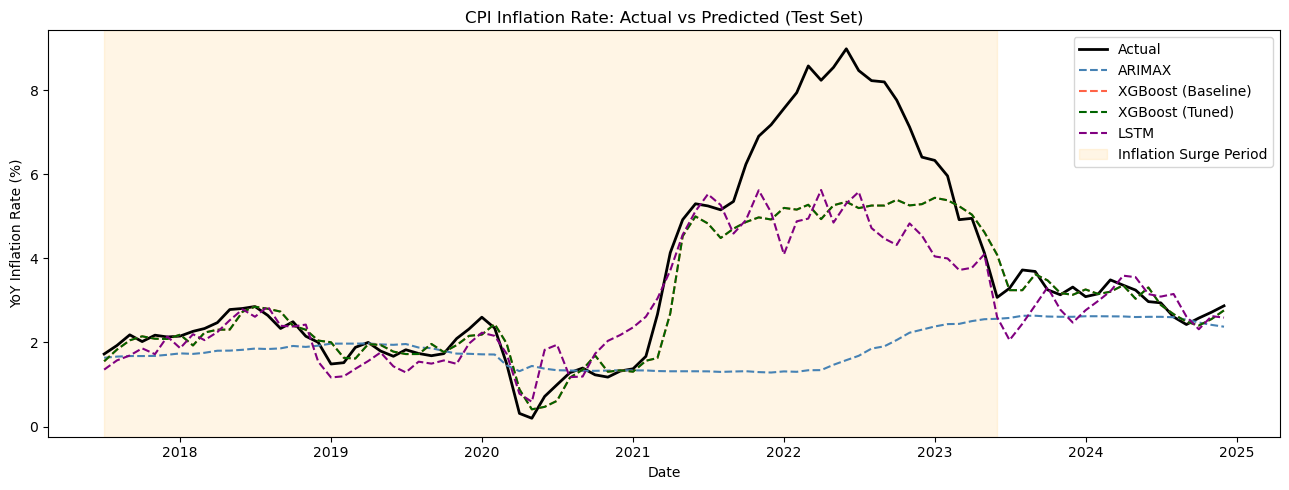

In [64]:
# Align LSTM predictions with test index
lstm_test_index = y_test.index[-len(lstm_pred):]

plt.figure(figsize=(13, 5))
plt.plot(y_test.index, y_test.values,        label="Actual",             color="black",     linewidth=2)
plt.plot(y_test.index, arimax_pred.values,   label="ARIMAX",             color="steelblue", linestyle="--")
plt.plot(y_test.index, xgb_pred,             label="XGBoost (Baseline)", color="tomato",    linestyle="--")
plt.plot(y_test.index, best_pred,            label="XGBoost (Tuned)",    color="darkgreen", linestyle="--")
plt.plot(lstm_test_index, lstm_pred,         label="LSTM",               color="purple",    linestyle="--")
plt.axvspan(y_test.index[0], pd.Timestamp("2023-06-01"),
            alpha=0.1, color="orange", label="Inflation Surge Period")
plt.title("CPI Inflation Rate: Actual vs Predicted (Test Set)")
plt.ylabel("YoY Inflation Rate (%)")
plt.xlabel("Date")
plt.legend()
plt.tight_layout()
plt.savefig("predictions.png", dpi=150, bbox_inches="tight")
plt.show()

### XGBoost Feature Importance

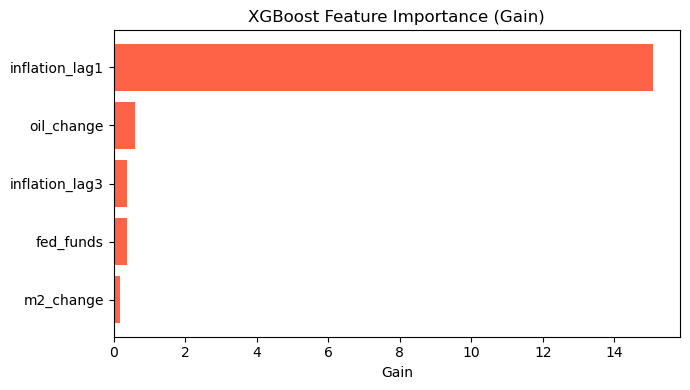

In [65]:
importance = xgb_model.get_booster().get_score(importance_type="gain")
imp_df = pd.DataFrame({
    "feature": list(importance.keys()),
    "importance": list(importance.values())
}).sort_values("importance", ascending=True)

plt.figure(figsize=(7, 4))
plt.barh(imp_df["feature"], imp_df["importance"], color="tomato")
plt.title("XGBoost Feature Importance (Gain)")
plt.xlabel("Gain")
plt.tight_layout()
plt.savefig("xgb_importance.png", dpi=150, bbox_inches="tight")
plt.show()

### Model Comparison

In [66]:
results = pd.DataFrame({
    "Model":   ["ARIMAX(3,1,0)", "XGBoost (Baseline)",
                "XGBoost (Tuned)", "LSTM"],
    "MAE":     [mae_arimax, mae_xgb, mae_best, mae_lstm],
    "RMSE":    [rmse_arimax, rmse_xgb, rmse_best, rmse_lstm]
})
print(results.to_string(index=False))

             Model      MAE     RMSE
     ARIMAX(3,1,0) 1.752343 2.835946
XGBoost (Baseline) 0.640984 1.146466
   XGBoost (Tuned) 0.640984 1.146466
              LSTM 0.845610 1.330828
